In [10]:
# ============================
# Import Required Libraries
# ============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

In [11]:
X_train = joblib.load("Demand_X_train.pkl")
X_test = joblib.load("Demand_X_test.pkl")

y_train = joblib.load("Demand_y_train.pkl")
y_test = joblib.load("Demand_y_test.pkl")

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

Training Features Shape : (100, 17)
Testing Features Shape  : (26, 17)

Training Target Shape : (100,)
Testing Target Shape  : (26,)


In [12]:
# ============================
# Hyperparameter Tuning - LightGBM
# ============================

tscv = TimeSeriesSplit(n_splits=5)

lgb_model = LGBMRegressor(
    random_state=42,
    verbose=-1,
    n_jobs=1          # IMPORTANT
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, -1],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [5, 10, 15, 20],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    n_iter=40,
    cv=tscv,
    scoring='r2',
    random_state=42,
    n_jobs=1,          # IMPORTANT
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [13]:
# =========================================================
# Experiment 2: L1 Feature Sparsity & Moderate Tree Capacity
# =========================================================

lgb_model = LGBMRegressor(
    max_depth=5,
    num_leaves=15,
    min_child_samples=10,
    reg_alpha=1.5,         # L1 penalty to prune redundant split gains from collinear features
    reg_lambda=3.0,        # Moderate L2 penalty on leaf weights
    colsample_bytree=0.8,
    subsample=0.8,
    learning_rate=0.03,
    n_estimators=300,
    random_state=42,
    verbose=-1,
    n_jobs=1
)

# Fit model
lgb_model.fit(X_train, y_train)

print("Experiment 2: Regularized LightGBM model trained successfully!")

Experiment 2: Regularized LightGBM model trained successfully!


In [14]:
# ============================
# Make Predictions
# ============================

# Training Predictions
y_train_pred = lgb_model.predict(X_train)

# Testing Predictions
y_test_pred = lgb_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [15]:
# ============================
# Model Evaluation
# ============================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# ---------- Training Metrics ----------

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
train_r2 = r2_score(y_train, y_train_pred)

# ---------- Testing Metrics ----------

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 50)
print("Training Performance")
print("=" * 50)

print(f"MAE  : {train_mae:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"MAPE : {train_mape:.2f}%")
print(f"R²   : {train_r2:.4f}")

print("\n")

print("=" * 50)
print("Testing Performance")
print("=" * 50)

print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"MAPE : {test_mape:.2f}%")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 78.24
RMSE : 137.95
MAPE : 0.91%
R²   : 0.9784


Testing Performance
MAE  : 580.46
RMSE : 677.66
MAPE : 5.27%
R²   : 0.5250


In [16]:
# ============================
# Feature Importance
# ============================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
3               Coal         362
10       Temperature         196
1           Rainfall         174
4            Nuclear         140
8        Small-Hydro         132
0           Humidity         131
2   Solar_Irradiance         112
6              Solar         108
16      Demand_Lag_3         107
9          Bio Power          91
14      Demand_Lag_1          83
15      Demand_Lag_2          76
7               Wind          71
5              Hydro          55
11              Year          43
13         Month_cos          29
12         Month_sin          28


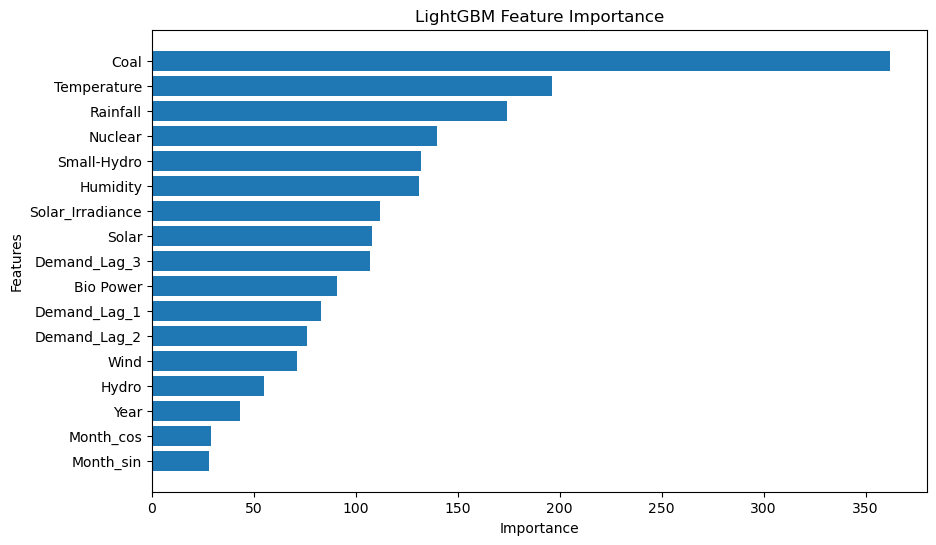

In [17]:
# ============================
# Feature Importance Plot
# ============================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("LightGBM Feature Importance")

plt.gca().invert_yaxis()

plt.show()